# Implementacion

## Librerias

In [166]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report,precision_score,recall_score,f1_score,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import label_binarize

In [167]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.base")

## Cargado de datos

In [168]:
df_url='https://docs.google.com/spreadsheets/d/1NJiaIRABEh1mJrqzP6bAYBkhBruBwUUzplHdXViv9-g/export?format=csv'
df=pd.read_csv(df_url)

## Funciones

In [169]:
def Summary(data, sheet):
    print(f"Hoja: {sheet}")

    # Crear la tabla de resumen
    resumen = {
        "Cantidad de filas": data.shape[0],
        "Cantidad de columnas": data.shape[1],
        "Datos faltantes": data.isnull().sum().sum(),
        "Filas duplicadas": data.duplicated().sum()
    }

    # Convertir el resumen en un DataFrame
    ResumenHoja = pd.DataFrame(resumen, index=["Resumen"])
    print("\nResumen:")
    display(ResumenHoja)

    print("\nEncabezado:")
    display(data.head())

In [170]:
def plot_multiclass_roc(model, X_test, y_test, classes):
    # Binarizar etiquetas (One-vs-Rest)
    y_bin = label_binarize(y_test, classes=classes)
    n_classes = y_bin.shape[1]

    # Obtener probabilidades
    y_score = model.predict_proba(X_test)

    # Calcular curva ROC y AUC por clase
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Promedio macro
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    roc_auc["macro"] = auc(all_fpr, mean_tpr)

    # Graficar
    plt.figure(figsize=(6,6))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], lw=2,
                 label=f"Clase {classes[i]} (AUC = {roc_auc[i]:.2f})")
    plt.plot(all_fpr, mean_tpr, color="black", linestyle="--",
             label=f"Macro promedio (AUC = {roc_auc['macro']:.2f})")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curvas ROC Multiclase")
    plt.legend(loc="lower right")
    plt.show()

    return roc_auc

## Analisis exploratorio de datos

In [171]:
Summary(df,'Datos pacientes')

Hoja: Datos pacientes

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,212691,17,0,0



Encabezado:


,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,1,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,3,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,5,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign


In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212691 entries, 0 to 212690
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Patient_ID           212691 non-null  int64  
 1   Age                  212691 non-null  int64  
 2   Gender               212691 non-null  object 
 3   Country              212691 non-null  object 
 4   Ethnicity            212691 non-null  object 
 5   Family_History       212691 non-null  object 
 6   Radiation_Exposure   212691 non-null  object 
 7   Iodine_Deficiency    212691 non-null  object 
 8   Smoking              212691 non-null  object 
 9   Obesity              212691 non-null  object 
 10  Diabetes             212691 non-null  object 
 11  TSH_Level            212691 non-null  float64
 12  T3_Level             212691 non-null  float64
 13  T4_Level             212691 non-null  float64
 14  Nodule_Size          212691 non-null  float64
 15  Thyroid_Cancer_Ri

In [173]:
df.describe()

,Patient_ID,Age,TSH_Level,T3_Level,T4_Level,Nodule_Size
count,212691.00000,212691.000000,212691.000000,212691.000000,212691.000000,212691.000000
mean,106346.00000,51.918497,5.045102,2.001727,8.246204,2.503403
std,61398.74739,21.632815,2.860264,0.866248,2.164188,1.444631
min,1.00000,15.000000,0.100000,0.500000,4.500000,0.000000
25%,53173.50000,33.000000,2.570000,1.250000,6.370000,1.250000
50%,106346.00000,52.000000,5.040000,2.000000,8.240000,2.510000
75%,159518.50000,71.000000,7.520000,2.750000,10.120000,3.760000
max,212691.00000,89.000000,10.000000,3.500000,12.000000,5.000000


In [174]:
df.Thyroid_Cancer_Risk.value_counts()

Thyroid_Cancer_Risk
Low       108388
Medium     72400
High       31903
Name: count, dtype: int64

In [175]:
sns.set_style("whitegrid")

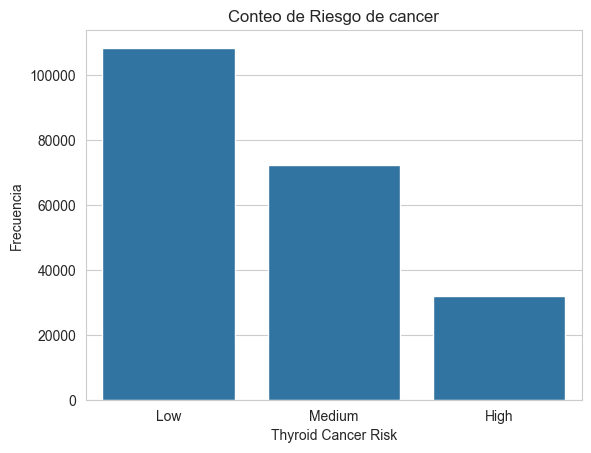

In [176]:
plt.title('Conteo de Riesgo de cancer')
sns.countplot(x=df.Thyroid_Cancer_Risk)
plt.xlabel('Thyroid Cancer Risk')
plt.ylabel('Frecuencia')
plt.show()

podemos observar que el dataset esta desbalanceado, tomaremos en cuenta esto mas adelante

realizaremos graficas de cada variable del dataset

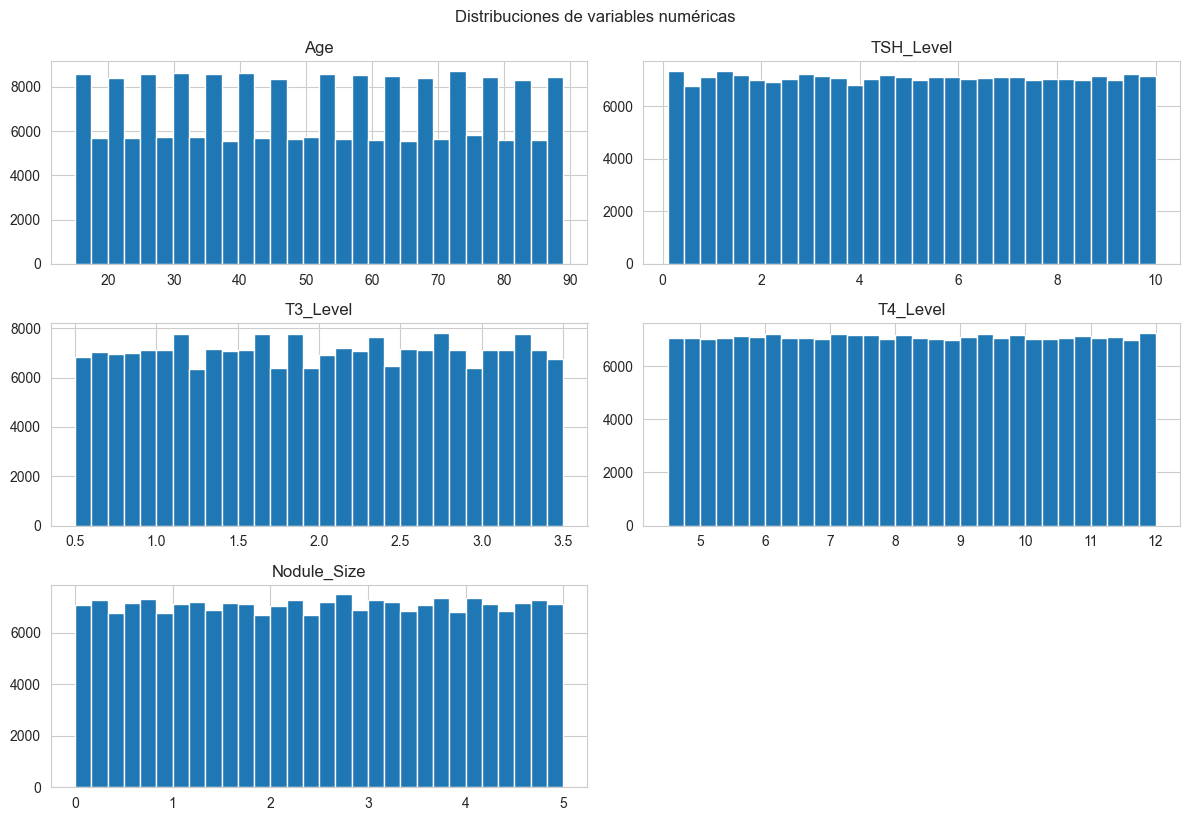

In [177]:
numericas = ['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size']
df[numericas].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.suptitle('Distribuciones de variables numéricas', y=1.02)
plt.show()

se realiza lo mismo para las variables categoricas y tambien se realiza el conteo de cada categoria

In [178]:
categoricas = ['Gender', 'Country', 'Ethnicity', 'Family_History', 'Radiation_Exposure',
               'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes', 'Diagnosis']

Gender
Female    127527
Male       85164
Name: count, dtype: int64


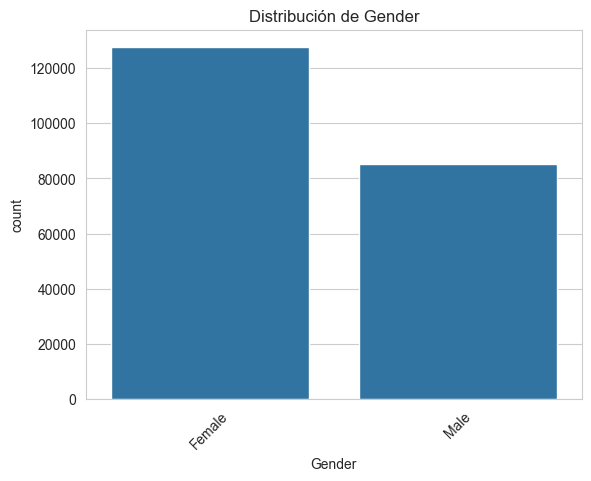

Country
India          42496
China          31978
Nigeria        31918
Brazil         21413
Russia         21297
Japan          16867
South Korea    14965
UK             10642
USA            10558
Germany        10557
Name: count, dtype: int64


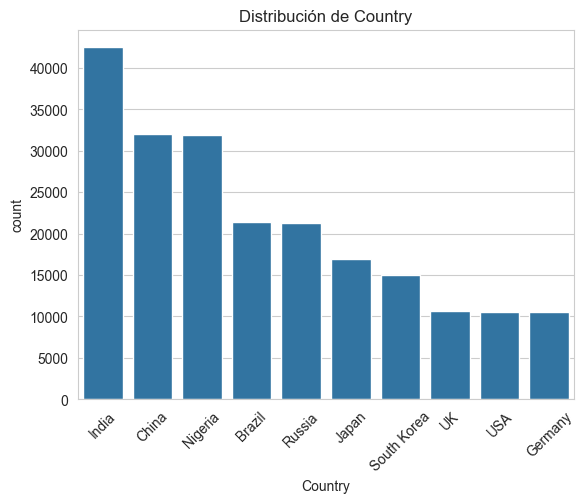

Ethnicity
Caucasian         63669
Asian             53261
African           42414
Hispanic          32012
Middle Eastern    21335
Name: count, dtype: int64


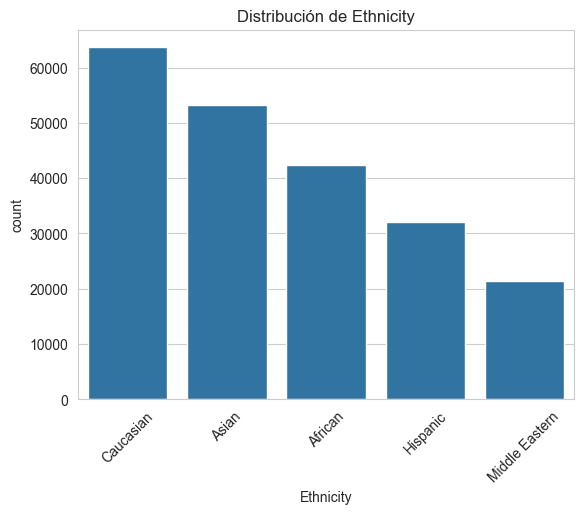

Family_History
No     148866
Yes     63825
Name: count, dtype: int64


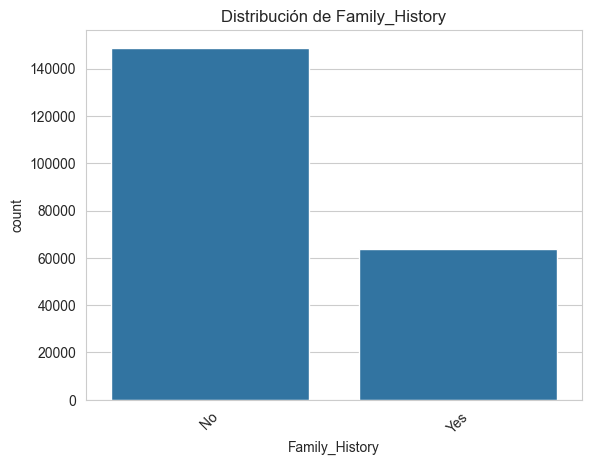

Radiation_Exposure
No     180831
Yes     31860
Name: count, dtype: int64


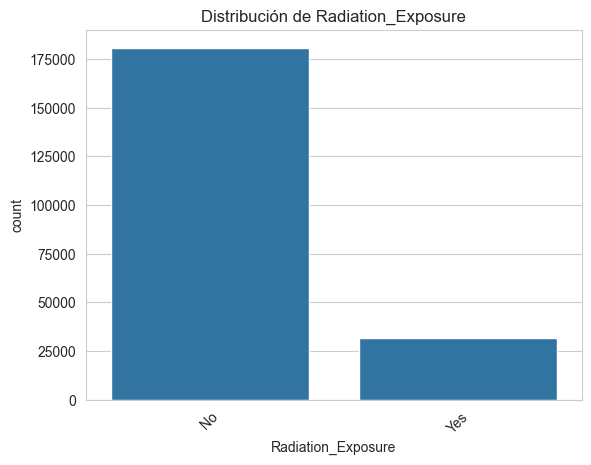

Iodine_Deficiency
No     159673
Yes     53018
Name: count, dtype: int64


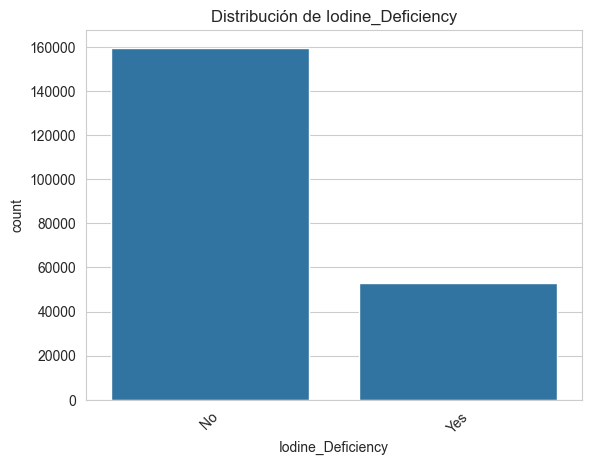

Smoking
No     170260
Yes     42431
Name: count, dtype: int64


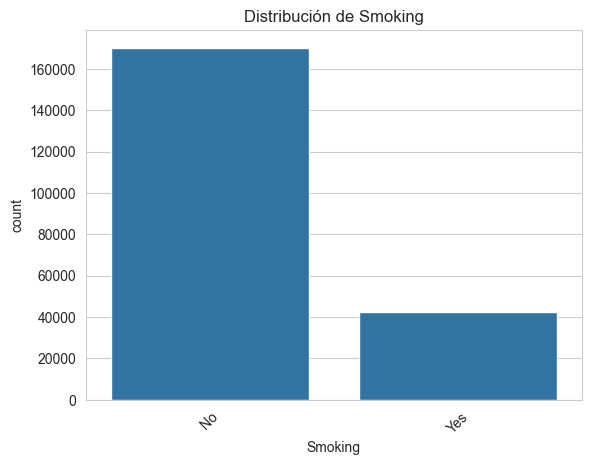

Obesity
No     148805
Yes     63886
Name: count, dtype: int64


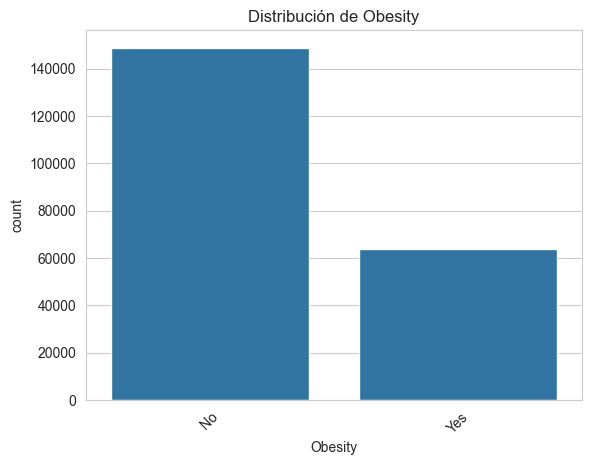

Diabetes
No     170098
Yes     42593
Name: count, dtype: int64


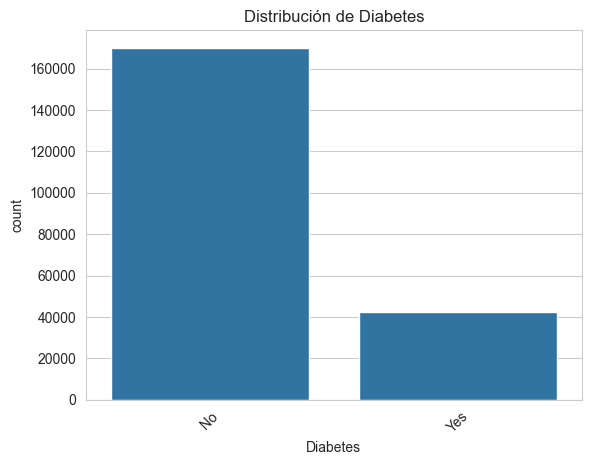

Diagnosis
Benign       163196
Malignant     49495
Name: count, dtype: int64


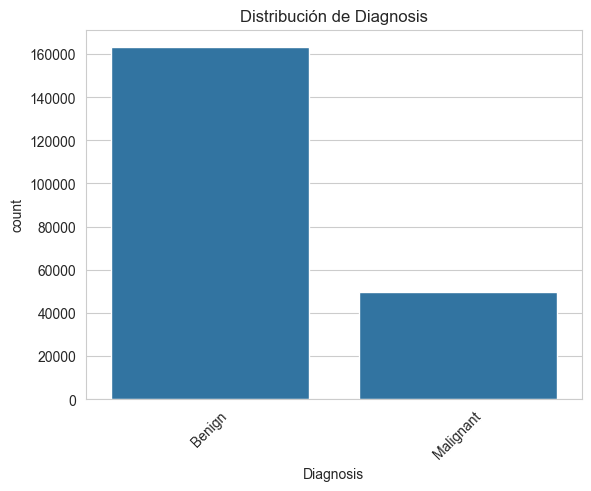

In [179]:
for col in categoricas:
    print(df[col].value_counts())
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=45)
    plt.show()

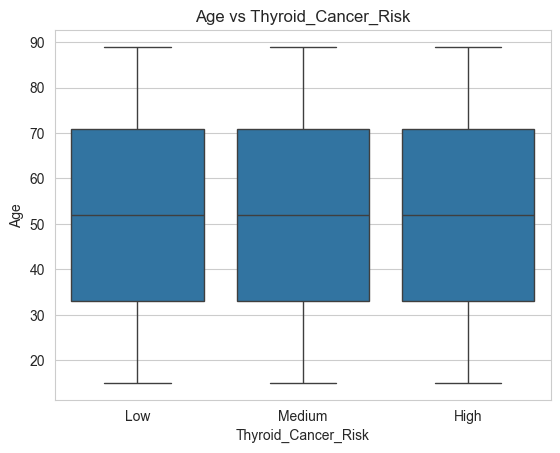

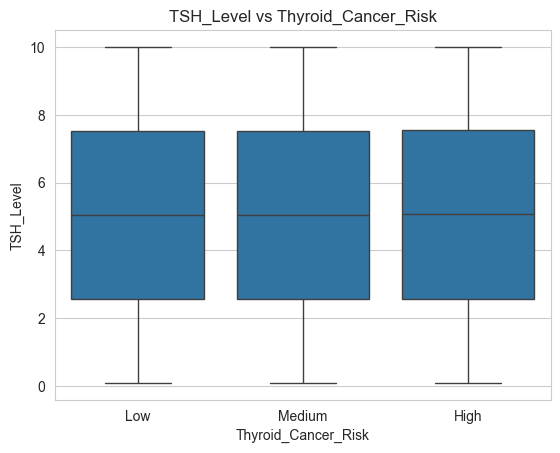

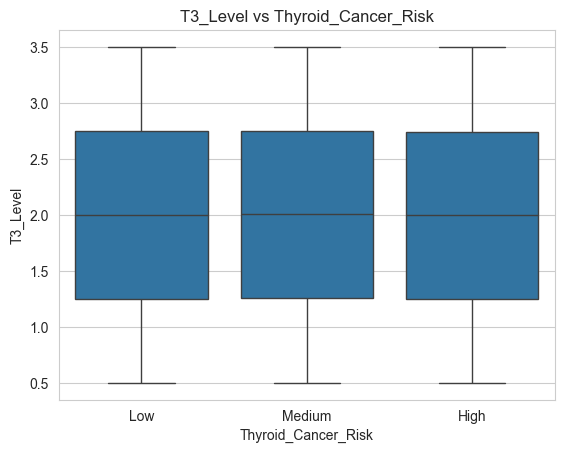

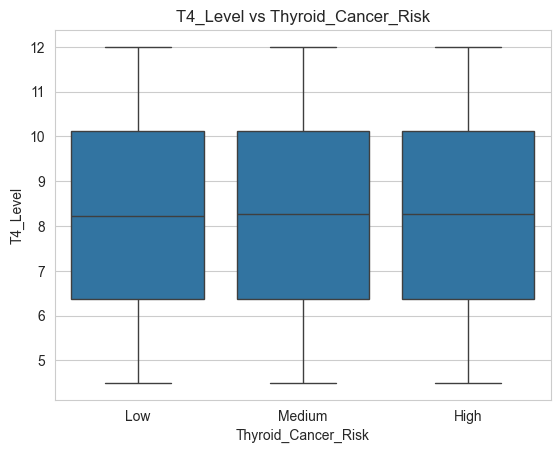

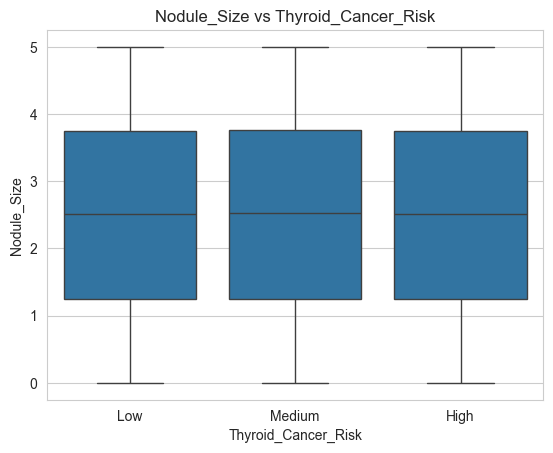

In [180]:
for col in numericas:
    sns.boxplot(data=df, x="Thyroid_Cancer_Risk", y=col, order=['Low', 'Medium', 'High'])
    plt.title(f'{col} vs {"Thyroid_Cancer_Risk"}')
    plt.show()

Se realizan comparaciones entre la variable objetivo y las categoricas y se examina el numero de personas que pertenecen a cada una de las categorias con respecto a las otras variables

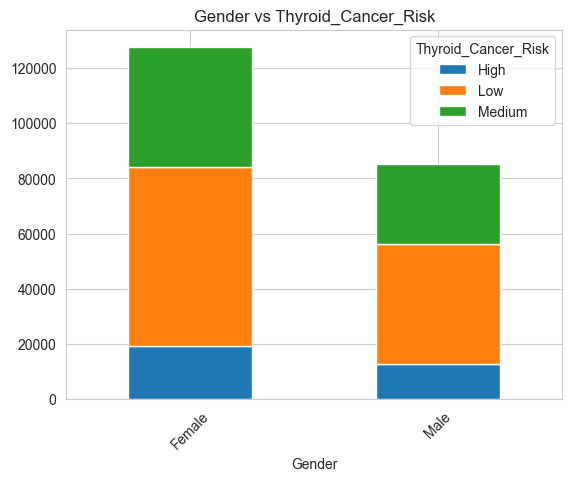

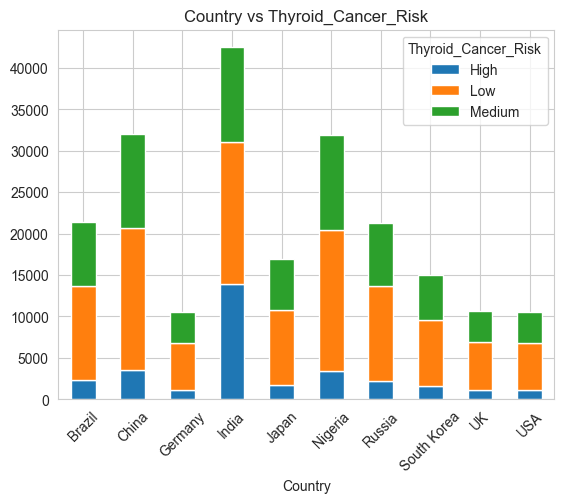

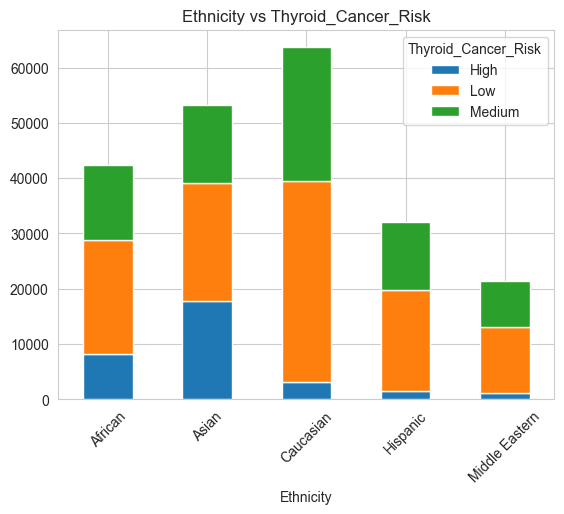

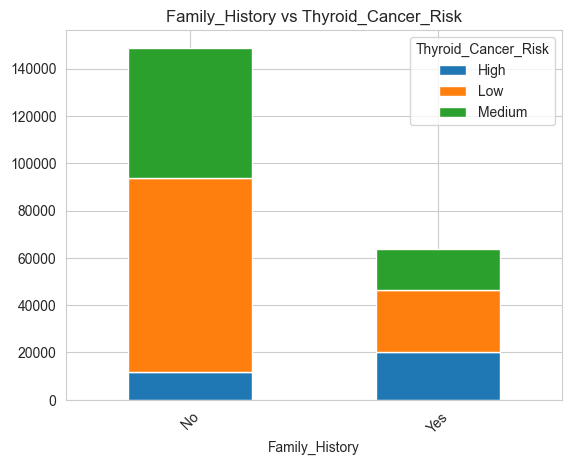

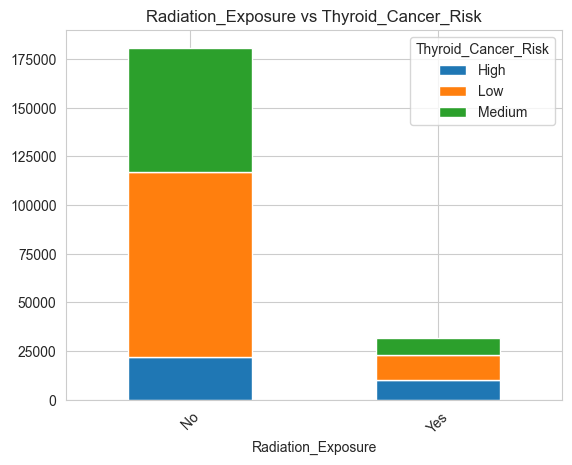

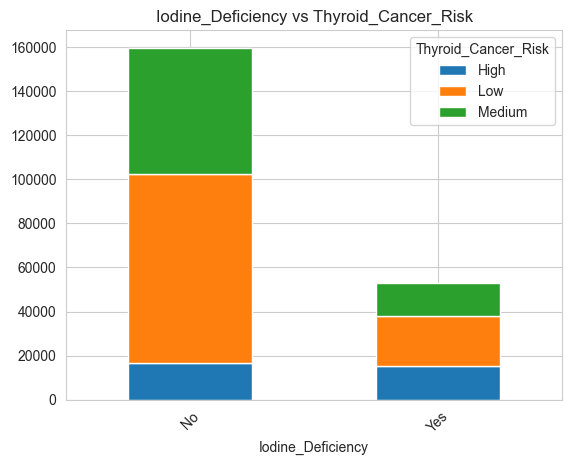

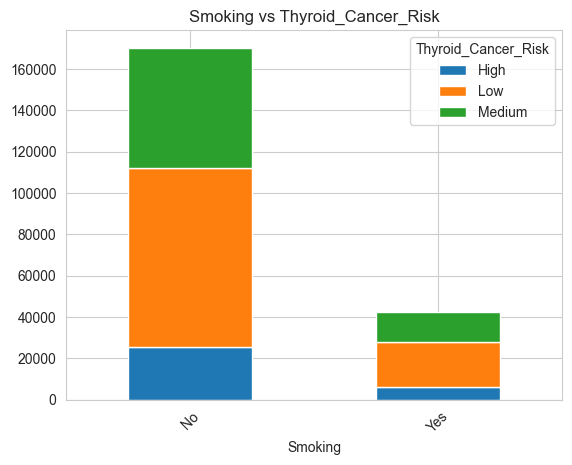

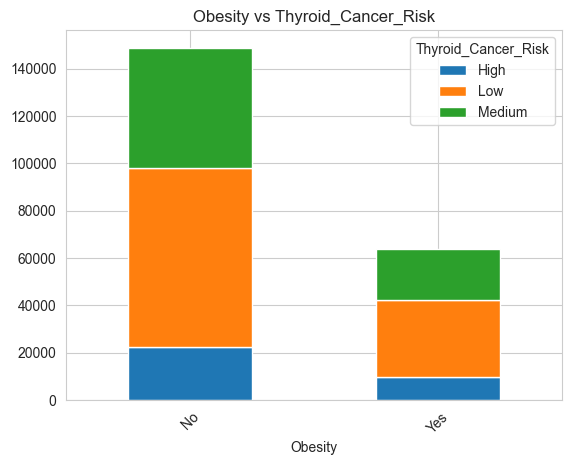

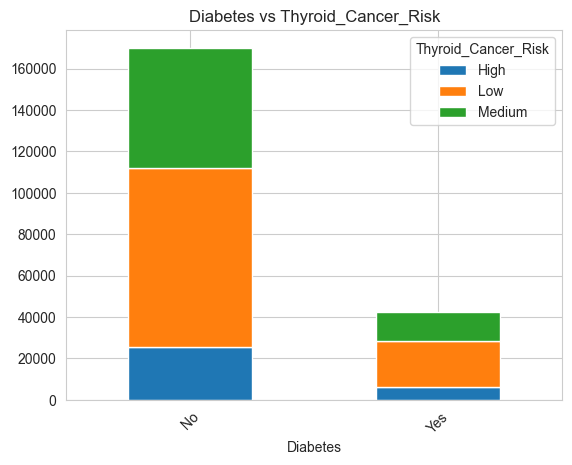

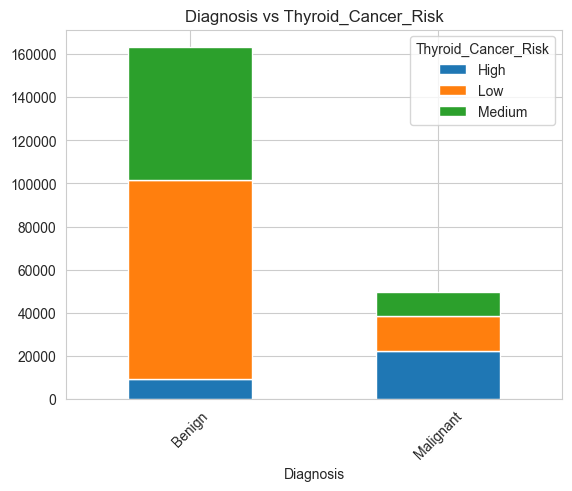

In [181]:
for col in categoricas:
    tabla = pd.crosstab(df[col], df['Thyroid_Cancer_Risk'])
    tabla.plot(kind='bar', stacked=True)
    plt.title(f'{col} vs Thyroid_Cancer_Risk')
    plt.xticks(rotation=45)
    plt.show()

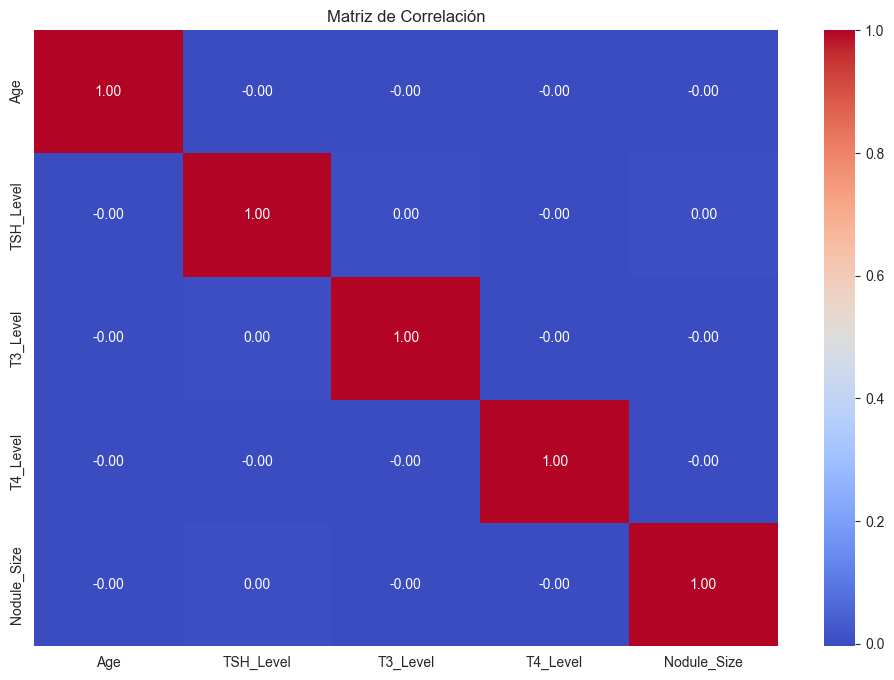

In [182]:
corr=df[numericas].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

## Split de los datos

In [183]:
X=df.drop(columns=['Thyroid_Cancer_Risk'])
Y=df['Thyroid_Cancer_Risk']

In [184]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0, stratify=Y)

## Preprocesamiento de datos

In [185]:
#categorical_idx = [X.columns.get_loc(col) for col in categoricas]

In [186]:
#smote_nc = SMOTENC(categorical_features=categorical_idx, random_state=0)
#X_train_res, y_train_res = smote_nc.fit_resample(X_train, y_train)

Se realiza la transformacion de categoricas

In [187]:
encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[categoricas])
X_test_cat  = encoder.transform(X_test[categoricas])

In [188]:
X_train_cat = pd.DataFrame(X_train_cat, columns=encoder.get_feature_names_out(categoricas))
X_test_cat  = pd.DataFrame(X_test_cat,  columns=encoder.get_feature_names_out(categoricas))

Se realiza el escalado de numericas

In [189]:
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numericas])
X_test_num  = scaler.transform(X_test[numericas])

In [190]:
X_train_num = pd.DataFrame(X_train_num, columns=numericas)
X_test_num  = pd.DataFrame(X_test_num,  columns=numericas)

In [191]:
X_train_final = pd.concat([X_train_num.reset_index(drop=True), X_train_cat.reset_index(drop=True)], axis=1)
X_test_final  = pd.concat([X_test_num.reset_index(drop=True),  X_test_cat.reset_index(drop=True)],  axis=1)

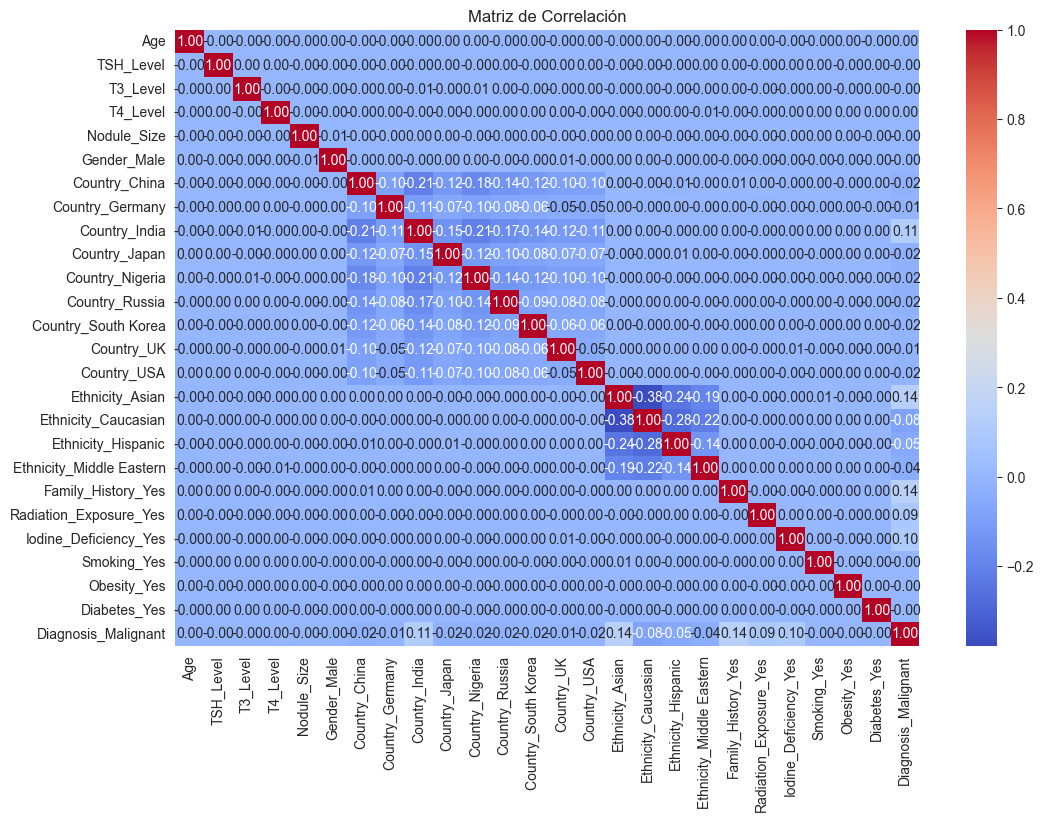

In [192]:
mat_corr=X_train_final.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(mat_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

In [193]:
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_final.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_final.values, i) 
                   for i in range(X_train_final.shape[1])]

print(vif_data.sort_values("VIF", ascending=False))

                     feature       VIF
16       Ethnicity_Caucasian  2.049344
15           Ethnicity_Asian  1.900163
8              Country_India  1.845439
5                Gender_Male  1.600013
6              Country_China  1.599202
10           Country_Nigeria  1.596607
17        Ethnicity_Hispanic  1.529831
19        Family_History_Yes  1.429798
11            Country_Russia  1.397129
25       Diagnosis_Malignant  1.395989
23               Obesity_Yes  1.391919
18  Ethnicity_Middle Eastern  1.348411
21     Iodine_Deficiency_Yes  1.322381
9              Country_Japan  1.315885
12       Country_South Korea  1.280807
24              Diabetes_Yes  1.231910
22               Smoking_Yes  1.229027
13                Country_UK  1.202751
14               Country_USA  1.197535
7            Country_Germany  1.195027
20    Radiation_Exposure_Yes  1.174618
4                Nodule_Size  1.000150
3                   T4_Level  1.000147
2                   T3_Level  1.000135
0                        

In [194]:
smote=SMOTE(random_state=0)
X_train_final_bal,y_train_bal=smote.fit_resample(X_train_final,y_train)

# Modelos

## Modelo Logistic

### Modelo Base

In [195]:
classes = np.unique(y_train)

In [196]:
log=LogisticRegression(max_iter=1000,random_state=0,multi_class="ovr",class_weight='balanced')

In [197]:
log.fit(X_train_final,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, multi_class='ovr',
                   random_state=0)

In [198]:
y_pred_log=log.predict(X_test_final)

In [199]:
accuracy_score(y_test,y_pred_log)

0.5637415077928489

In [200]:
precision_score(y_test, y_pred_log, average="macro")

0.5241481685624211

In [201]:
recall_score(y_test, y_pred_log, average="macro")

0.6073104618721518

In [202]:
f1_score(y_test, y_pred_log, average="macro")

0.5340702531873526

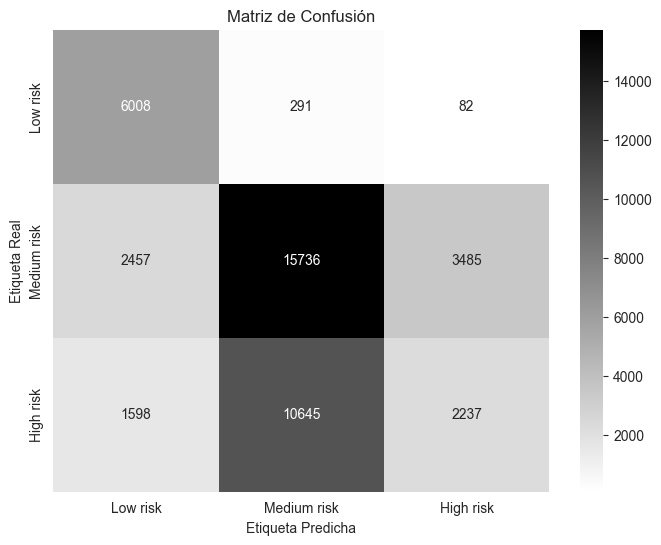

In [203]:
conf_matrix_log = confusion_matrix(y_test, y_pred_log).astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_log, annot=True, fmt="d", cmap="gray_r", 
            xticklabels=['Low risk', 'Medium risk', 'High risk'], 
            yticklabels=['Low risk', 'Medium risk', 'High risk'])

plt.xlabel("Etiqueta Predicha")
plt.ylabel("Etiqueta Real")
plt.title("Matriz de Confusión")
plt.show()

In [204]:
print(classification_report(y_test,y_pred_log, labels=['Low','Medium','High']))

              precision    recall  f1-score   support

         Low       0.59      0.73      0.65     21678
      Medium       0.39      0.15      0.22     14480
        High       0.60      0.94      0.73      6381

    accuracy                           0.56     42539
   macro avg       0.52      0.61      0.53     42539
weighted avg       0.52      0.56      0.52     42539



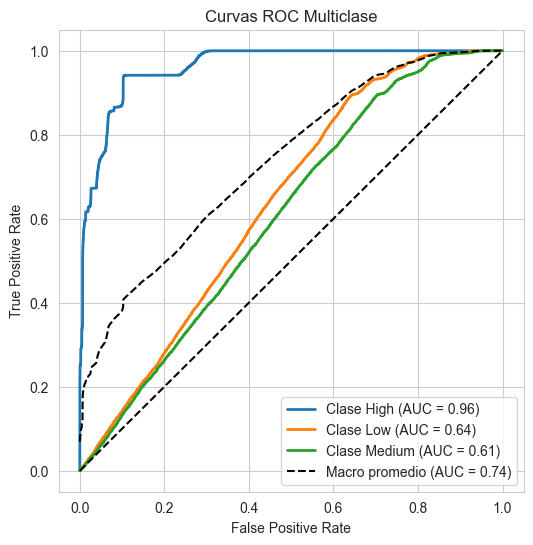

{0: np.float64(0.9618240779408842), 1: np.float64(0.6376680309926773), 2: np.float64(0.6069811510040308), 'macro': np.float64(0.7355102308686545)}


In [205]:
roc_results = plot_multiclass_roc(log, X_test_final, y_test, classes)
print(roc_results)

### Gridsearch Logistic

In [206]:
param_grid_log = {
    "C": [0.01,0.1, 1, 10,100],
    "solver": ["lbfgs","saga"]
}

In [207]:
grid_log = GridSearchCV(log, param_grid=param_grid_log, cv=5, scoring="f1_macro")

In [208]:
grid_log.fit(X_train_final,y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000, multi_class='ovr',
                                          random_state=0),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'solver': ['lbfgs', 'saga']},
             scoring='f1_macro')

In [209]:
print("Logistic GridSearch - Mejor f1:", grid_log.best_score_)
print("Logistic GridSearch - Params:", grid_log.best_params_)

Logistic GridSearch - Mejor f1: 0.5382331031929547
Logistic GridSearch - Params: {'C': 1, 'solver': 'lbfgs'}


In [210]:
grid_log_roc = GridSearchCV(log, param_grid=param_grid_log, cv=5, scoring="roc_auc_ovr")

In [211]:
grid_log_roc.fit(X_train_final,y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000, multi_class='ovr',
                                          random_state=0),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'solver': ['lbfgs', 'saga']},
             scoring='roc_auc_ovr')

In [212]:
print("Logistic GridSearch - Mejor f1:", grid_log_roc.best_score_)
print("Logistic GridSearch - Params:", grid_log_roc.best_params_)

Logistic GridSearch - Mejor f1: 0.7362363307910595
Logistic GridSearch - Params: {'C': 100, 'solver': 'saga'}


### Revision Metricas Logistic

In [213]:
best_log=LogisticRegression(max_iter=1000,class_weight='balanced',C=100,multi_class='ovr', solver= 'saga')

In [214]:
best_log.fit(X_train_final,y_train)

LogisticRegression(C=100, class_weight='balanced', max_iter=1000,
                   multi_class='ovr', solver='saga')

In [215]:
y_log=best_log.predict(X_test_final)

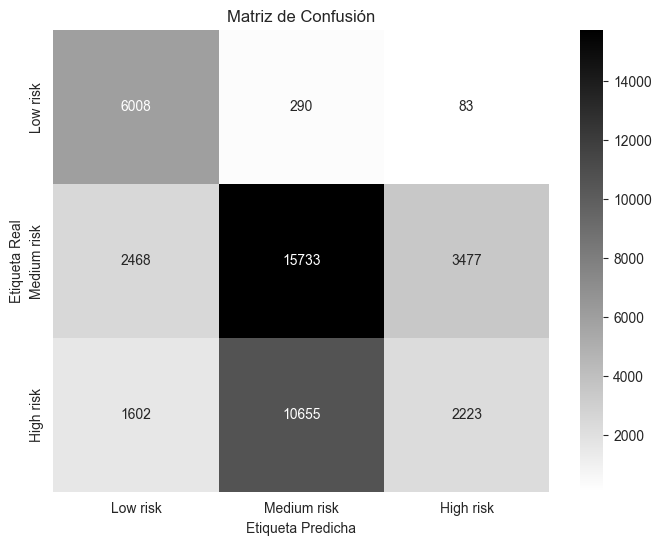

In [216]:
conf_matrix_log_best = confusion_matrix(y_test, y_log).astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_log_best, annot=True, fmt="d", cmap="gray_r", 
            xticklabels=['Low risk', 'Medium risk', 'High risk'], 
            yticklabels=['Low risk', 'Medium risk', 'High risk'])

plt.xlabel("Etiqueta Predicha")
plt.ylabel("Etiqueta Real")
plt.title("Matriz de Confusión")
plt.show()

Low risk (real):
- Correctamente predichos: 6008
- Clasificados como Medium: 291
- Clasificados como High: 82

Medium risk (real):
- Clasificados como Low: 2456
- Correctamente predichos: 15734
- Clasificados como High: 3488

High risk (real):
- Clasificados como Low: 1598
- Clasificados como Medium: 10644
- Correctamente predichos: 2238

In [217]:
print(classification_report(y_test,y_log, labels=['Low','Medium','High']))

              precision    recall  f1-score   support

         Low       0.59      0.73      0.65     21678
      Medium       0.38      0.15      0.22     14480
        High       0.60      0.94      0.73      6381

    accuracy                           0.56     42539
   macro avg       0.52      0.61      0.53     42539
weighted avg       0.52      0.56      0.52     42539



High risk
- Precision = 0.60 de todas las veces que predijo "High", 60% fueron correctas.
- Recall = 0.94 casi todos los verdaderos "High" fueron detectados.
- F1 = 0.73 balance aceptable, el mejor de las tres clases.

El modelo sobre-detecta "High" (muchos falsos positivos), pero no se le escapan casi casos reales.

Low risk
- Precision = 0.59
- Recall = 0.73
- F1 = 0.65.

Desempeño moderado y balanceado. El modelo se defiende relativamente bien con esta clase.

Medium risk
- Precision = 0.39
- Recall = 0.15
- F1 = 0.22.

Aquí está el problema mayor: el modelo casi nunca identifica bien los casos Medium (recall bajísimo). Esto explica por qué en la matriz de confusión tantos Medium fueron confundidos con High o Low.

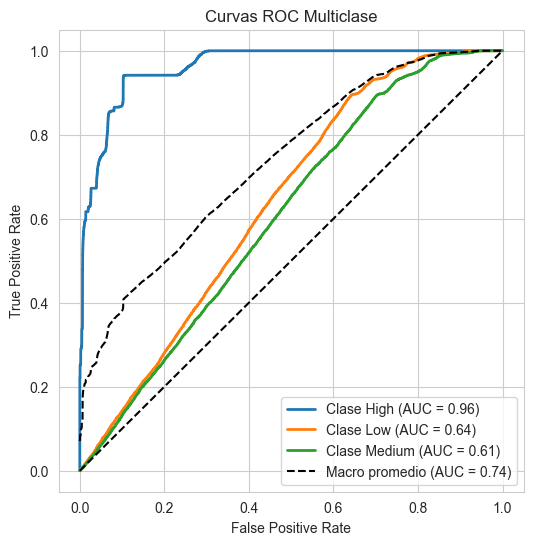

{0: np.float64(0.9619144152361513), 1: np.float64(0.637684129182507), 2: np.float64(0.60695307037519), 'macro': np.float64(0.7355357862246336)}


In [218]:
roc_results = plot_multiclass_roc(best_log, X_test_final, y_test, classes)
print(roc_results)

Clase High (AUC = 0.96):
- Excelente desempeño: el modelo discrimina muy bien los casos de alto riesgo frente a los demás.
- Esto contrasta con la matriz de confusión, donde vimos que muchos High risk se confundían con Medium risk. El AUC mide la capacidad de discriminación con diferentes umbrales, mientras que la matriz de confusión depende del umbral fijo usado (probablemente 0.5).

Clase Low (AUC = 0.64)
- Desempeño bajo-medio. El modelo tiene dificultades para distinguir correctamente los casos de bajo riesgo.
- En la matriz, vimos que “Low risk” se predice mejor que “High risk”, pero el AUC refleja que no es tan fácil separarlo de las otras clases en el espacio de probabilidades.

Clase Medium (AUC = 0.61)
- Es la clase más problemática. Aunque en la matriz de confusión parecía la más fuerte (15,735 aciertos), el AUC muestra que la discriminación es débil.
- Esto pasa porque el modelo tiende a predecir Medium risk “por defecto”, lo cual aumenta los aciertos en esa categoría pero disminuye la calidad de la separación probabilística.
- Macro promedio (AUC = 0.74)
- Balance general aceptable, pero claramente con clases desbalanceadas en rendimiento.


El promedio está inflado por el buen AUC de la clase High.

## Modelo KNN

### Modelo base

In [219]:
classes = np.unique(y_train)

In [220]:
Knn=KNeighborsClassifier(weights='distance')

In [221]:
Knn.fit(X_train_final_bal,y_train_bal)

KNeighborsClassifier(weights='distance')

In [222]:
y_pred_knn=Knn.predict(X_test_final)

In [223]:
accuracy_score(y_test,y_pred_knn)

0.5559133971179389

In [224]:
precision_score(y_test,y_pred_knn,average='macro')

0.6068909180715993

In [225]:
recall_score(y_test,y_pred_knn,average='macro')

0.6377124875158556

In [226]:
f1_score(y_test,y_pred_knn,average='macro')

0.6183404026127168

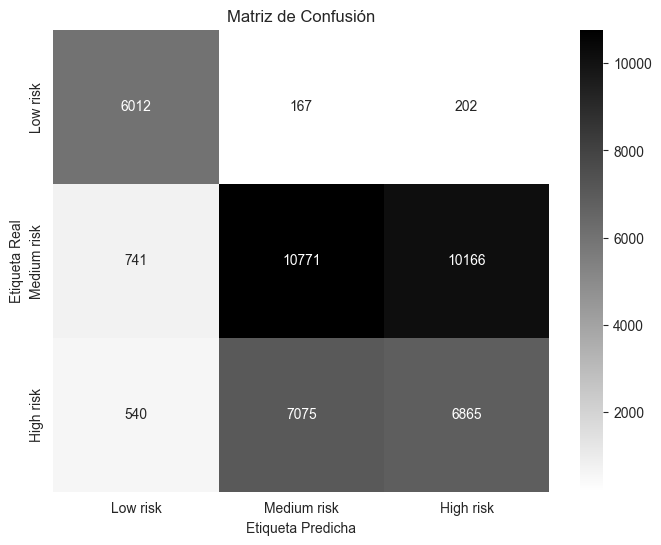

In [227]:
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn).astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt="d", cmap="gray_r", 
            xticklabels=['Low risk', 'Medium risk', 'High risk'], 
            yticklabels=['Low risk', 'Medium risk', 'High risk'])

plt.xlabel("Etiqueta Predicha")
plt.ylabel("Etiqueta Real")
plt.title("Matriz de Confusión")
plt.show()

In [228]:
print(classification_report(y_test,y_pred_knn, labels=['Low','Medium','High']))

              precision    recall  f1-score   support

         Low       0.60      0.50      0.54     21678
      Medium       0.40      0.47      0.43     14480
        High       0.82      0.94      0.88      6381

    accuracy                           0.56     42539
   macro avg       0.61      0.64      0.62     42539
weighted avg       0.56      0.56      0.56     42539



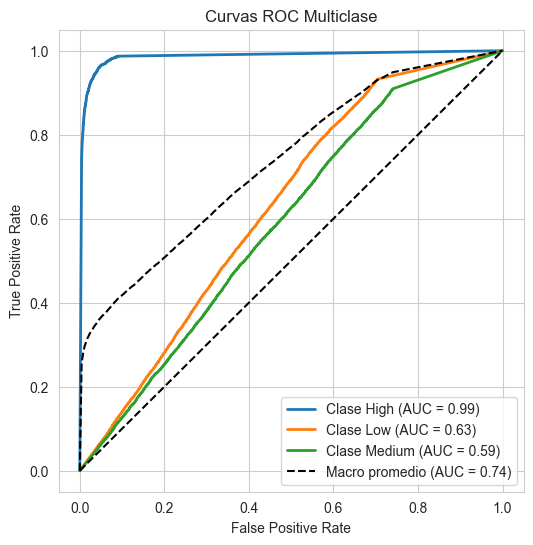

{0: np.float64(0.9864605575527887), 1: np.float64(0.6289900585230674), 2: np.float64(0.5914397597288585), 'macro': np.float64(0.7356475132936463)}


In [229]:
roc_results = plot_multiclass_roc(Knn, X_test_final, y_test, classes)
print(roc_results)

### Gridsearch KNN

In [230]:
param_knn={
    'n_neighbors': range(1,21)
}

In [231]:
grid_knn=GridSearchCV(Knn,param_grid=param_knn,cv=5,scoring='f1_macro')

In [232]:
grid_knn.fit(X_train_final_bal,y_train_bal)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(weights='distance'),
             param_grid={'n_neighbors': range(1, 21)}, scoring='f1_macro')

In [233]:
print("KNN GridSearch - Mejor f1:", grid_knn.best_score_)
print("KNN GridSearch - Params:", grid_knn.best_params_)

KNN GridSearch - Mejor f1: 0.7727458807780889
KNN GridSearch - Params: {'n_neighbors': 1}


In [234]:
grid_knn_roc=GridSearchCV(Knn,param_grid=param_knn,cv=5,scoring='roc_auc_ovr')

In [235]:
grid_knn_roc.fit(X_train_final_bal,y_train_bal)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(weights='distance'),
             param_grid={'n_neighbors': range(1, 21)}, scoring='roc_auc_ovr')

In [236]:
print("KNN GridSearch - Mejor roc:", grid_knn_roc.best_score_)
print("KNN GridSearch - Params:", grid_knn_roc.best_params_)

KNN GridSearch - Mejor roc: 0.8976567907440227
KNN GridSearch - Params: {'n_neighbors': 6}


### Evaluacion Metricas Modelo KNN

In [291]:
best_knn=KNeighborsClassifier(n_neighbors=6,weights='distance')

In [292]:
best_knn.fit(X_train_final_bal,y_train_bal)

KNeighborsClassifier(n_neighbors=6, weights='distance')

In [293]:
y_knn=best_knn.predict(X_test_final)

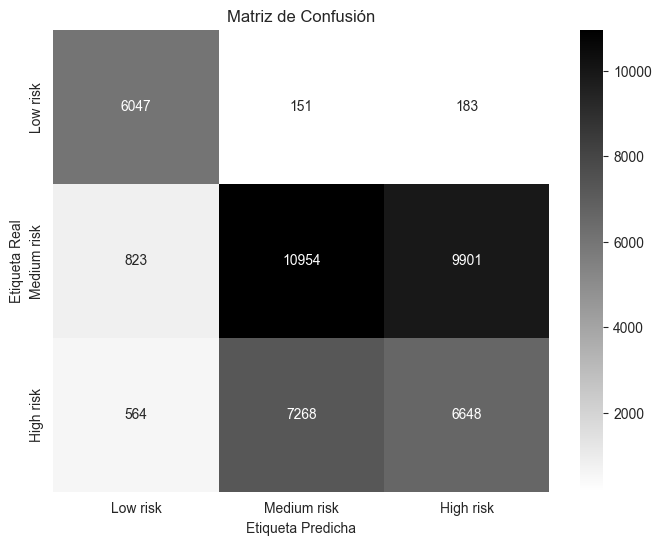

In [294]:
conf_matrix_knn_best = confusion_matrix(y_test, y_knn).astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn_best, annot=True, fmt="d", cmap="gray_r", 
            xticklabels=['Low risk', 'Medium risk', 'High risk'], 
            yticklabels=['Low risk', 'Medium risk', 'High risk'])

plt.xlabel("Etiqueta Predicha")
plt.ylabel("Etiqueta Real")
plt.title("Matriz de Confusión")
plt.show()

Low risk (real):
- Correctamente predichos: 6047
- Clasificados como Medium: 151
- Clasificados como High: 183

Medium risk (real):
- Clasificados como Low: 823
- Correctamente predichos: 10954
- Clasificados como High: 9901

High risk (real):
- Clasificados como Low: 564
- Clasificados como Medium: 7268
- Correctamente predichos: 6648

In [295]:
print(classification_report(y_test,y_knn, labels=['Low','Medium','High']))

              precision    recall  f1-score   support

         Low       0.60      0.51      0.55     21678
      Medium       0.40      0.46      0.43     14480
        High       0.81      0.95      0.88      6381

    accuracy                           0.56     42539
   macro avg       0.60      0.64      0.62     42539
weighted avg       0.56      0.56      0.56     42539



High risk
- Precision = 0.81 de todas las veces que predijo "High", 60% fueron correctas.
- Recall = 0.95 casi todos los verdaderos "High" fueron detectados.
- F1 = 0.88 balance aceptable, el mejor de las tres clases.

El modelo sobre-detecta "High" (muchos falsos positivos), pero no se le escapan casi casos reales.

Low risk
- Precision = 0.60
- Recall = 0.51
- F1 = 0.55

Desempeño moderado y balanceado. El modelo se defiende relativamente bien con esta clase.

Medium risk
- Precision = 0.40
- Recall = 0.46
- F1 = 0.43

Estos son los resultados menos problematicos de entre todos los modelos puesto que medium está bastante mas balanceado sin perder eficacia en high

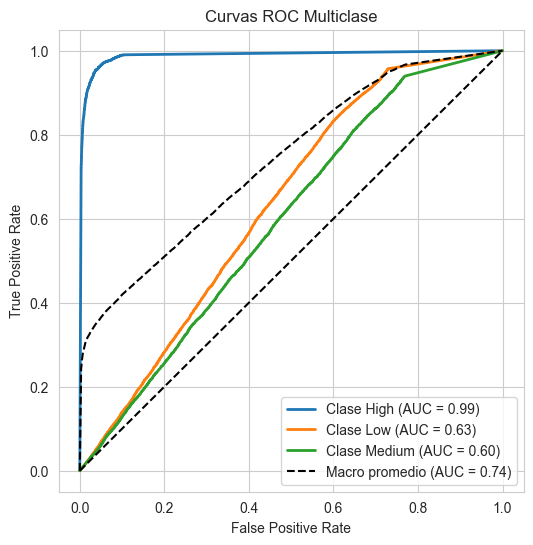

{0: np.float64(0.9884761545470838), 1: np.float64(0.633290489814359), 2: np.float64(0.5955003124336072), 'macro': np.float64(0.7391072280046468)}


In [296]:
roc_results = plot_multiclass_roc(best_knn, X_test_final, y_test, classes)
print(roc_results)

Clase High (AUC = 0.99):
- Excelente desempeño: el modelo discrimina muy bien los casos de alto riesgo frente a los demás.
- Esto contrasta con la matriz de confusión, donde vimos que muchos High risk se confundían con Medium risk. El AUC mide la capacidad de discriminación con diferentes umbrales, mientras que la matriz de confusión depende del umbral fijo usado (probablemente 0.5).

Clase Low (AUC = 0.63)
- Desempeño bajo-medio. El modelo tiene dificultades para distinguir correctamente los casos de bajo riesgo.
- En la matriz, vimos que “Low risk” se predice mejor que “High risk”, pero el AUC refleja que no es tan fácil separarlo de las otras clases en el espacio de probabilidades.

Clase Medium (AUC = 0.60)
- Es la clase más problemática. Aunque en la matriz de confusión parecía la más fuerte (15,735 aciertos), el AUC muestra que la discriminación es débil.
- Esto pasa porque el modelo tiende a predecir Medium risk “por defecto”, lo cual aumenta los aciertos en esa categoría pero disminuye la calidad de la separación probabilística.
- Macro promedio (AUC = 0.74)
- Balance general aceptable, pero claramente con clases desbalanceadas en rendimiento.


El promedio está inflado por el buen AUC de la clase High.

## Modelo Ridge 

### Modelo base

In [243]:
classes = np.unique(y_train)

In [244]:
log_ridge=LogisticRegression(max_iter=1000,random_state=0,multi_class="ovr",class_weight='balanced',penalty='l2')

In [245]:
log_ridge.fit(X_train_final,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, multi_class='ovr',
                   random_state=0)

In [246]:
y_pred_ridge=log_ridge.predict(X_test_final)

In [247]:
print(accuracy_score(y_test, y_pred_ridge))

0.5637415077928489


In [248]:
precision_score(y_test, y_pred_ridge,average='macro')

0.5241481685624211

In [249]:
recall_score(y_test, y_pred_ridge,average='macro')

0.6073104618721518

In [250]:
f1_score(y_test,y_pred_ridge,average='macro')

0.5340702531873526

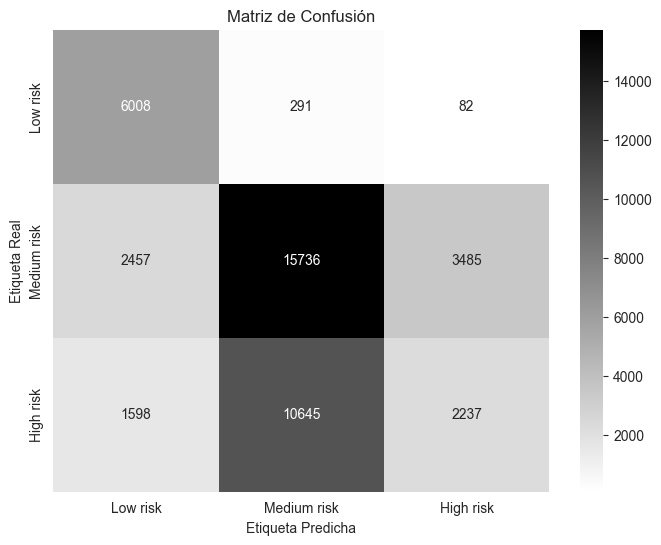

In [251]:
conf_matrix_log_ridge = confusion_matrix(y_test, y_pred_ridge).astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_log_ridge, annot=True, fmt="d", cmap="gray_r", 
            xticklabels=['Low risk', 'Medium risk', 'High risk'], 
            yticklabels=['Low risk', 'Medium risk', 'High risk'])

plt.xlabel("Etiqueta Predicha")
plt.ylabel("Etiqueta Real")
plt.title("Matriz de Confusión")
plt.show()

In [252]:
print(classification_report(y_test,y_pred_ridge, labels=['Low','Medium','High']))

              precision    recall  f1-score   support

         Low       0.59      0.73      0.65     21678
      Medium       0.39      0.15      0.22     14480
        High       0.60      0.94      0.73      6381

    accuracy                           0.56     42539
   macro avg       0.52      0.61      0.53     42539
weighted avg       0.52      0.56      0.52     42539



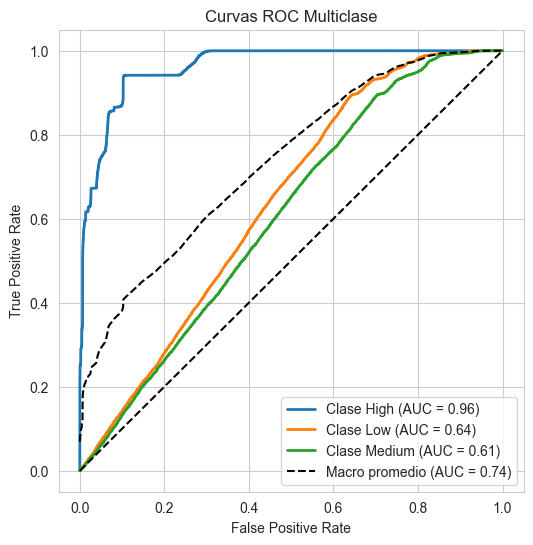

{0: np.float64(0.9618240779408842), 1: np.float64(0.6376680309926773), 2: np.float64(0.6069811510040308), 'macro': np.float64(0.7355102308686545)}


In [253]:
roc_results = plot_multiclass_roc(log_ridge, X_test_final, y_test, classes)
print(roc_results)

### Gridsearch Modelo Ridge

In [254]:
param_grid_log = {
    "C": [0.01,0.1, 1, 10,100],
    "solver": ["lbfgs","saga"]
}

In [255]:
grid_log_ridge=GridSearchCV(log_ridge,param_grid=param_grid_log,cv=5,scoring='f1_macro')

In [256]:
grid_log_ridge.fit(X_train_final,y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000, multi_class='ovr',
                                          random_state=0),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'solver': ['lbfgs', 'saga']},
             scoring='f1_macro')

In [257]:
print("Ridge GridSearch - Mejor f1:", grid_log_ridge.best_score_)
print("Ridge GridSearch - Params:", grid_log_ridge.best_params_)

Ridge GridSearch - Mejor f1: 0.5382331031929547
Ridge GridSearch - Params: {'C': 1, 'solver': 'lbfgs'}


In [258]:
grid_log_ridge_roc=GridSearchCV(log_ridge,param_grid=param_grid_log,cv=5,scoring='roc_auc_ovr')

In [259]:
grid_log_ridge_roc.fit(X_train_final,y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000, multi_class='ovr',
                                          random_state=0),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'solver': ['lbfgs', 'saga']},
             scoring='roc_auc_ovr')

In [260]:
print("Ridge GridSearch - Mejor roc_auc:", grid_log_ridge_roc.best_score_)
print("Ridge GridSearch - Params:", grid_log_ridge_roc.best_params_)

Ridge GridSearch - Mejor roc_auc: 0.7362363307910595
Ridge GridSearch - Params: {'C': 100, 'solver': 'saga'}


###  Revision Metricas Ridge

In [261]:
best_ridge=LogisticRegression(max_iter=1000,multi_class='ovr',solver='saga',C=100,class_weight='balanced',penalty='l2')

In [262]:
best_ridge.fit(X_train_final,y_train)

LogisticRegression(C=100, class_weight='balanced', max_iter=1000,
                   multi_class='ovr', solver='saga')

In [263]:
y_ridge=best_ridge.predict(X_test_final)

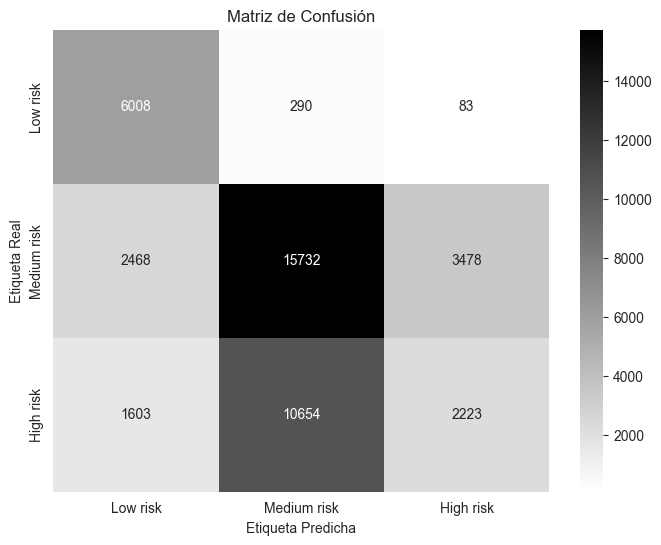

In [264]:
conf_matrix_log_ridge_best = confusion_matrix(y_test, y_ridge).astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_log_ridge_best, annot=True, fmt="d", cmap="gray_r", 
            xticklabels=['Low risk', 'Medium risk', 'High risk'], 
            yticklabels=['Low risk', 'Medium risk', 'High risk'])

plt.xlabel("Etiqueta Predicha")
plt.ylabel("Etiqueta Real")
plt.title("Matriz de Confusión")
plt.show()

Low risk (real):
- Correctamente predichos: 6008
- Clasificados como Medium: 290
- Clasificados como High: 83

Medium risk (real):
- Clasificados como Low: 2468
- Correctamente predichos: 15735
- Clasificados como High: 3475

High risk (real):
- Clasificados como Low: 1604
- Clasificados como Medium: 10653
- Correctamente predichos: 2223

In [265]:
print(classification_report(y_test,y_ridge, labels=['Low','Medium','High']))

              precision    recall  f1-score   support

         Low       0.59      0.73      0.65     21678
      Medium       0.38      0.15      0.22     14480
        High       0.60      0.94      0.73      6381

    accuracy                           0.56     42539
   macro avg       0.52      0.61      0.53     42539
weighted avg       0.52      0.56      0.52     42539



High risk
- Precision = 0.60 de todas las veces que predijo "High", 60% fueron correctas.
- Recall = 0.94 casi todos los verdaderos "High" fueron detectados.
- F1 = 0.73 balance aceptable, el mejor de las tres clases.

El modelo sobre-detecta "High" (muchos falsos positivos), pero no se le escapan casi casos reales.

Low risk
- Precision = 0.59
- Recall = 0.73
- F1 = 0.65.

Desempeño moderado y balanceado. El modelo se defiende relativamente bien con esta clase.

Medium risk
- Precision = 0.38
- Recall = 0.15
- F1 = 0.22.

Aquí está el problema mayor: el modelo casi nunca identifica bien los casos Medium (recall bajísimo). Esto explica por qué en la matriz de confusión tantos Medium fueron confundidos con High o Low.

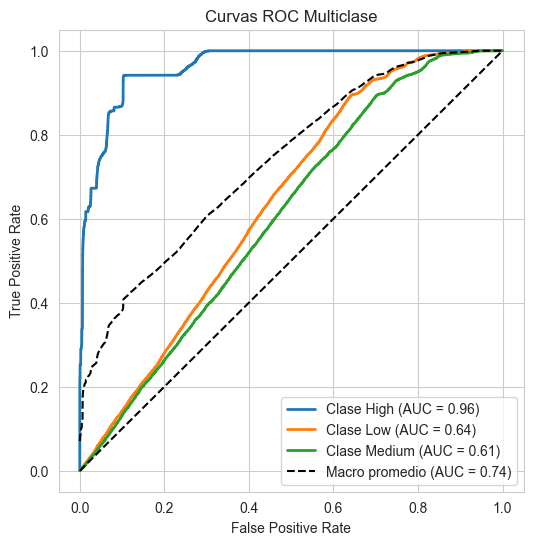

{0: np.float64(0.9619136480864481), 1: np.float64(0.6376861303997867), 2: np.float64(0.606956075585797), 'macro': np.float64(0.7355373316655698)}


In [266]:
roc_results = plot_multiclass_roc(best_ridge, X_test_final, y_test, classes)
print(roc_results)

Clase High (AUC = 0.96):
- Excelente desempeño: el modelo discrimina muy bien los casos de alto riesgo frente a los demás.
- Esto contrasta con la matriz de confusión, donde vimos que muchos High risk se confundían con Medium risk. El AUC mide la capacidad de discriminación con diferentes umbrales, mientras que la matriz de confusión depende del umbral fijo usado (probablemente 0.5).

Clase Low (AUC = 0.64)
- Desempeño bajo-medio. El modelo tiene dificultades para distinguir correctamente los casos de bajo riesgo.
- En la matriz, vimos que “Low risk” se predice mejor que “High risk”, pero el AUC refleja que no es tan fácil separarlo de las otras clases en el espacio de probabilidades.

Clase Medium (AUC = 0.61)
- Es la clase más problemática. Aunque en la matriz de confusión parecía la más fuerte (15,735 aciertos), el AUC muestra que la discriminación es débil.
- Esto pasa porque el modelo tiende a predecir Medium risk “por defecto”, lo cual aumenta los aciertos en esa categoría pero disminuye la calidad de la separación probabilística.
- Macro promedio (AUC = 0.74)
- Balance general aceptable, pero claramente con clases desbalanceadas en rendimiento.


El promedio está inflado por el buen AUC de la clase High.

## Modelo Lasso

### Modelo Base

In [267]:
classes = np.unique(y_train)

In [268]:
log_lasso=LogisticRegression(max_iter=1000,random_state=0,multi_class="ovr",class_weight='balanced',penalty='l1',solver='saga')

In [269]:
log_lasso.fit(X_train_final,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, multi_class='ovr',
                   penalty='l1', random_state=0, solver='saga')

In [270]:
y_pred_lasso=log_lasso.predict(X_test_final)

In [271]:
print(accuracy_score(y_test, y_pred_lasso))

0.5636474764333905


In [272]:
precision_score(y_test, y_pred_lasso,average='macro')

0.5234975724590708

In [273]:
recall_score(y_test,y_pred_lasso,average='macro')

0.6070043576448177

In [274]:
f1_score(y_test,y_pred_lasso,average='macro')

0.5331539345371298

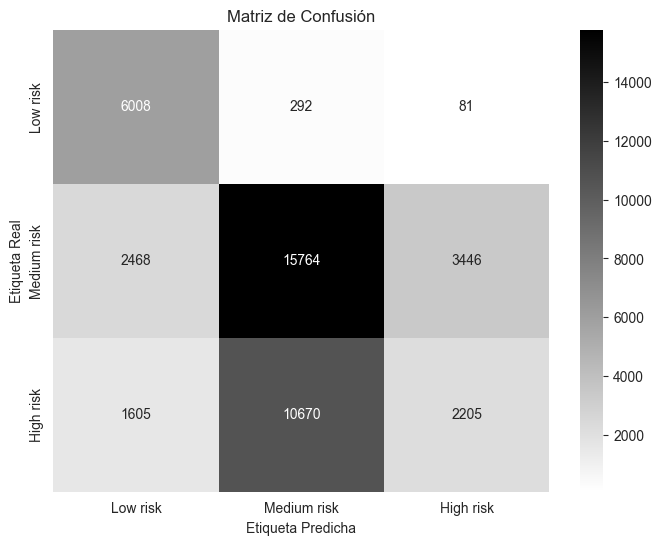

In [275]:
conf_matrix_log_lasso = confusion_matrix(y_test, y_pred_lasso).astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_log_lasso, annot=True, fmt="d", cmap="gray_r", 
            xticklabels=['Low risk', 'Medium risk', 'High risk'], 
            yticklabels=['Low risk', 'Medium risk', 'High risk'])

plt.xlabel("Etiqueta Predicha")
plt.ylabel("Etiqueta Real")
plt.title("Matriz de Confusión")
plt.show()

In [276]:
print(classification_report(y_test,y_pred_lasso, labels=['Low','Medium','High']))

              precision    recall  f1-score   support

         Low       0.59      0.73      0.65     21678
      Medium       0.38      0.15      0.22     14480
        High       0.60      0.94      0.73      6381

    accuracy                           0.56     42539
   macro avg       0.52      0.61      0.53     42539
weighted avg       0.52      0.56      0.52     42539



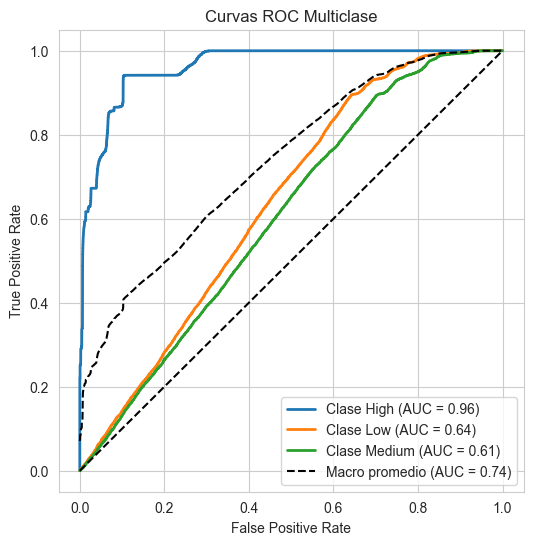

{0: np.float64(0.9619099900392762), 1: np.float64(0.6376842309018385), 2: np.float64(0.6069667328846734), 'macro': np.float64(0.7355389791586877)}


In [277]:
roc_results = plot_multiclass_roc(log_lasso, X_test_final, y_test, classes)
print(roc_results)

### Gridsearch Lasso

In [278]:
param_grid_lasso = {
    "C": [0.01,0.1, 1, 10,100],
}

In [279]:
grid_log_lasso=GridSearchCV(log_lasso,param_grid=param_grid_lasso,cv=5,scoring='f1_macro')

In [280]:
grid_log_lasso.fit(X_train_final,y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000, multi_class='ovr',
                                          penalty='l1', random_state=0,
                                          solver='saga'),
             param_grid={'C': [0.01, 0.1, 1, 10, 100]}, scoring='f1_macro')

In [281]:
print("Lasso GridSearch - Mejor f1:", grid_log_lasso.best_score_)
print("Lasso GridSearch - Params:", grid_log_lasso.best_params_)

Lasso GridSearch - Mejor f1: 0.538100553978753
Lasso GridSearch - Params: {'C': 100}


In [282]:
grid_log_lasso_roc=GridSearchCV(log_lasso,param_grid=param_grid_lasso,cv=5,scoring='roc_auc_ovr')

In [283]:
grid_log_lasso_roc.fit(X_train_final,y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000, multi_class='ovr',
                                          penalty='l1', random_state=0,
                                          solver='saga'),
             param_grid={'C': [0.01, 0.1, 1, 10, 100]}, scoring='roc_auc_ovr')

In [284]:
print("Lasso GridSearch - Mejor roc_auc:", grid_log_lasso_roc.best_score_)
print("Lasso GridSearch - Params:", grid_log_lasso_roc.best_params_)

Lasso GridSearch - Mejor roc_auc: 0.7362362728905827
Lasso GridSearch - Params: {'C': 100}


### Evaluacion Metricas Lasso

In [285]:
best_lasso=LogisticRegression(max_iter=1000,random_state=0,solver='saga',multi_class='ovr',penalty='l1',class_weight='balanced',C=100)

In [286]:
best_lasso.fit(X_train_final,y_train)

LogisticRegression(C=100, class_weight='balanced', max_iter=1000,
                   multi_class='ovr', penalty='l1', random_state=0,
                   solver='saga')

In [287]:
y_lasso=best_lasso.predict(X_test_final)

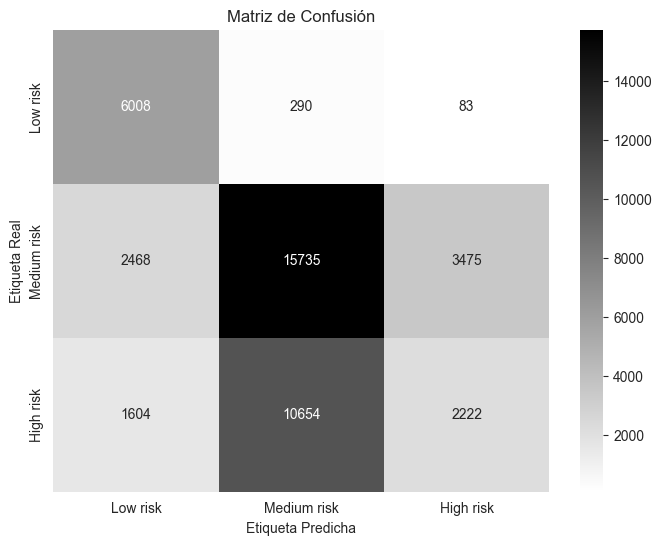

In [288]:
conf_matrix_log_bestlasso = confusion_matrix(y_test, y_lasso).astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_log_bestlasso, annot=True, fmt="d", cmap="gray_r", 
            xticklabels=['Low risk', 'Medium risk', 'High risk'], 
            yticklabels=['Low risk', 'Medium risk', 'High risk'])

plt.xlabel("Etiqueta Predicha")
plt.ylabel("Etiqueta Real")
plt.title("Matriz de Confusión")
plt.show()

Low risk (real):
- Correctamente predichos: 6008
- Clasificados como Medium: 290
- Clasificados como High: 83

Medium risk (real):
- Clasificados como Low: 2468
- Correctamente predichos: 15735
- Clasificados como High: 3475

High risk (real):
- Clasificados como Low: 1604
- Clasificados como Medium: 10654
- Correctamente predichos: 2222

conclusiones:
- Medium risk domina: El modelo tiene un muy buen desempeño clasificando "Medium risk" (15,735 aciertos).
- Confusión con Medium risk: Muchos casos de High risk (10,654) y Low risk (290) están siendo clasificados como Medium. Esto sugiere que el modelo tiende a sobrepredecir la clase Medium.
- High risk subrepresentado: Aunque hay 14,480 casos reales de High risk (1604 + 10654 + 2222), solo 2222 fueron identificados correctamente, lo cual indica un recall bajo para esta clase.
- Low risk es el más balanceado: Tiene buena identificación (6008 correctos) con relativamente pocos errores.

In [289]:
print(classification_report(y_test,y_lasso, labels=['Low','Medium','High']))

              precision    recall  f1-score   support

         Low       0.59      0.73      0.65     21678
      Medium       0.38      0.15      0.22     14480
        High       0.60      0.94      0.73      6381

    accuracy                           0.56     42539
   macro avg       0.52      0.61      0.53     42539
weighted avg       0.52      0.56      0.52     42539



High risk
- Precision = 0.60 de todas las veces que predijo "High", 60% fueron correctas.
- Recall = 0.94 casi todos los verdaderos "High" fueron detectados.
- F1 = 0.73 balance aceptable, el mejor de las tres clases.

El modelo sobre-detecta "High" (muchos falsos positivos), pero no se le escapan casi casos reales.

Low risk
- Precision = 0.59
- Recall = 0.73
- F1 = 0.65.

Desempeño moderado y balanceado. El modelo se defiende relativamente bien con esta clase.

Medium risk
- Precision = 0.38
- Recall = 0.15
- F1 = 0.22.

Aquí está el problema mayor: el modelo casi nunca identifica bien los casos Medium (recall bajísimo). Esto explica por qué en la matriz de confusión tantos Medium fueron confundidos con High o Low.

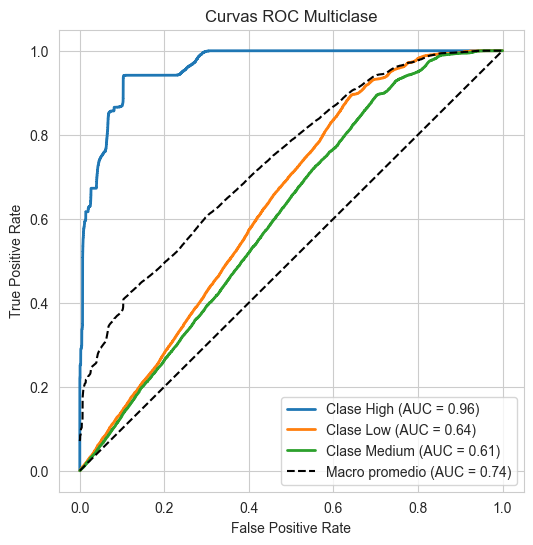

{0: np.float64(0.9619133403597311), 1: np.float64(0.6376851485871102), 2: np.float64(0.6069551058454373), 'macro': np.float64(0.7355362720877159)}


In [290]:
roc_results = plot_multiclass_roc(best_lasso, X_test_final, y_test, classes)
print(roc_results)

Clase High (AUC = 0.96):
- Excelente desempeño: el modelo discrimina muy bien los casos de alto riesgo frente a los demás.
- Esto contrasta con la matriz de confusión, donde vimos que muchos High risk se confundían con Medium risk. El AUC mide la capacidad de discriminación con diferentes umbrales, mientras que la matriz de confusión depende del umbral fijo usado (probablemente 0.5).

Clase Low (AUC = 0.64)
- Desempeño bajo-medio. El modelo tiene dificultades para distinguir correctamente los casos de bajo riesgo.
- En la matriz, vimos que “Low risk” se predice mejor que “High risk”, pero el AUC refleja que no es tan fácil separarlo de las otras clases en el espacio de probabilidades.

Clase Medium (AUC = 0.61)
- Es la clase más problemática. Aunque en la matriz de confusión parecía la más fuerte (15,735 aciertos), el AUC muestra que la discriminación es débil.
- Esto pasa porque el modelo tiende a predecir Medium risk “por defecto”, lo cual aumenta los aciertos en esa categoría pero disminuye la calidad de la separación probabilística.
- Macro promedio (AUC = 0.74)
- Balance general aceptable, pero claramente con clases desbalanceadas en rendimiento.


El promedio está inflado por el buen AUC de la clase High.

## Conclusiones generales del entregable 2

Se implementaron y compararon diferentes modelos de clasificación multiclase (Ridge, Lasso, Regresión Logística y KNN) con el fin de predecir el riesgo de cáncer de tiroides en tres niveles: Low, Medium y High. El objetivo principal fue dar prioridad a la detección de los casos High y Medium, ya que estos representan un mayor riesgo y normalmente requieren estudios médicos adicionales.

El modelo que obtuvo el mejor desempeño fue KNN, alcanzando un AUC de 0.99 para la clase High, lo que indica una excelente capacidad de discriminación en los casos más críticos. Además, mostró un recall de 0.95 y un F1-score de 0.88 en la clase High, reduciendo así el riesgo de falsos negativos en esta categoría. Aunque el rendimiento en la clase Medium fue más bajo (AUC = 0.60, F1-score = 0.43), el modelo mantuvo un equilibrio razonable con la clase Low (F1-score = 0.55).

De manera global, el modelo alcanzó una accuracy del 56% y un macro promedio de AUC de 0.74, lo que refleja un comportamiento aceptable en un problema donde las clases no son igualmente críticas.

En conclusión, KNN se posiciona como el modelo más adecuado para este escenario, ya que cumple con el objetivo clínico de priorizar la detección de los casos de mayor riesgo (High), sin sacrificar demasiado el desempeño en las demás clases. Esto lo convierte en una herramienta prometedora para apoyar la toma de decisiones médicas y reducir la probabilidad de pasar por alto pacientes con mayor probabilidad de desarrollar complicaciones.